<a href="https://colab.research.google.com/github/serlysetyani/Thesis/blob/main/Aspect%20Extraction_LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** **
#### Step 1: Loading Data <a class="anchor\" id="load_data"></a>
** **

In [ ]:
# Importing modules
import pandas as pd
import os

os.chdir('..')

# Read data into papers
papers = pd.read_csv('/content/dataset.csv',encoding = 'unicode_escape', error_bad_lines=False, sep='\t')


# Print head
papers.head()

,content
0,Sudah saatnya Bibit memiliki mode gelap (dark ...
1,"Setelah update, dan fitur baru di tambahkan, j..."
2,Sangat mudah dipahami oleh pemula. Dan ada ban...
3,"Selalu puas dengan apps bibit,banyak pilihan r..."
4,(Terimakasih____ atas peningkatan performa apl...


** **
#### Step 2: Data Cleaning <a class="anchor\" id="clean_data"></a>
** **

Since the goal of this analysis is to perform topic modeling, let's focus only on the text data from each paper, and drop other metadata columns. Also, for the demonstration, we'll only look at 100 papers

In [ ]:
# Remove the columns
#papers = papers.drop(columns=['id', 'event_type', 'pdf_name'], axis=1).sample(100)

# Print out the first rows of papers
papers.head()

,content
0,Sudah saatnya Bibit memiliki mode gelap (dark ...
1,"Setelah update, dan fitur baru di tambahkan, j..."
2,Sangat mudah dipahami oleh pemula. Dan ada ban...
3,"Selalu puas dengan apps bibit,banyak pilihan r..."
4,(Terimakasih____ atas peningkatan performa apl...


##### Remove punctuation/lower casing

Next, let’s perform a simple preprocessing on the content of `paper_text` column to make them more amenable for analysis, and reliable results. To do that, we’ll use a regular expression to remove any punctuation, and then lowercase the text

In [ ]:
# Load the regular expression library
import re

# Remove punctuation
papers['content_text_processed'] = \
papers['content'].map(lambda x: re.sub('[,\.!?]', '', x))

# Convert the titles to lowercase
papers['content_text_processed'] = \
papers['content_text_processed'].map(lambda x: x.lower())

# Print out the first rows of papers
papers['content_text_processed'].head()

0    sudah saatnya bibit memiliki mode gelap (dark ...
1    setelah update dan fitur baru di tambahkan jad...
2    sangat mudah dipahami oleh pemula dan ada bany...
3    selalu puas dengan apps bibitbanyak pilihan re...
4    (terimakasih____ atas peningkatan performa apl...
Name: content_text_processed, dtype: object

** **
#### Step 3: Exploratory Analysis <a class="anchor\" id="eda"></a>
** **

To verify whether the preprocessing, we’ll make a simple word cloud using the `wordcloud` package to get a visual representation of most common words. It is key to understanding the data and ensuring we are on the right track, and if any more preprocessing is necessary before training the model.

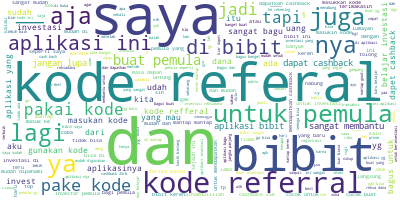

In [ ]:
# Import the wordcloud library
from wordcloud import WordCloud

# Join the different processed titles together.
long_string = ','.join(list(papers['content_text_processed'].values))

# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

** **
#### Step 4: Prepare text for LDA analysis <a class="anchor\" id="data_preparation"></a>
** **

Next, let’s work to transform the textual data in a format that will serve as an input for training LDA model. We start by tokenizing the text and removing stopwords. Next, we convert the tokenized object into a corpus and dictionary.

In [ ]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = stopwords.words('indonesian')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]


data = papers.paper_text_processed.values.tolist()
data_words = list(sent_to_words(data))

# remove stop words
data_words = remove_stopwords(data_words)

print(data_words[:1][0][:30])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['bibit', 'memiliki', 'mode', 'gelap', 'dark', 'mode', 'mendukung', 'sistem', 'navigasi', 'android', 'pembelian', 'mudah', 'aplikasi', 'sekedar', 'gestur', 'membatalkan', 'opsi', 'pembelian', 'tampilan', 'portofolio', 'butuh', 'dipercantik', 'senada', 'android', 'mohon', 'dioptimalkan', 'android', 'prosesor', 'exynos', 'series']


In [ ]:
import gensim.corpora as corpora

# Create Dictionary
id2word = corpora.Dictionary(data_words)

# Create Corpus
texts = data_words

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1][0][:30])

[(0, 3), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 2), (14, 1), (15, 1), (16, 1), (17, 1), (18, 2), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1)]


** **
#### Step 5: LDA model tranining <a class="anchor\" id="train_model"></a>
** **

To keep things simple, we'll keep all the parameters to default except for inputting the number of topics. For this tutorial, we will build a model with 10 topics where each topic is a combination of keywords, and each keyword contributes a certain weightage to the topic.

In [ ]:
from pprint import pprint

# number of topics
num_topics = 10

# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)

# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

Output streaming akan dipotong hingga 5000 baris terakhir.
/usr/local/lib/python3.8/dist-packages/gensim/models/ldamodel.py:1077: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  score += np.sum(cnt * logsumexp(Elogthetad + Elogbeta[:, int(id)]) for id, cnt in doc)
/usr/local/lib/python3.8/dist-packages/gensim/models/ldamodel.py:1077: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  score += np.sum(cnt * logsumexp(Elogthetad + Elogbeta[:, int(id)]) for id, cnt in doc)
/usr/local/lib/python3.8/dist-packages/gensim/models/ldamodel.py:1077: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  score += np

[(0,
  '0.022*"mantappp" + 0.022*"suka" + 0.016*"kereeen" + 0.012*"bibit" + '
  '0.012*"apk" + 0.011*"ga" + 0.010*"aplikasi" + 0.009*"gk" + 0.009*"apps" + '
  '0.008*"nya"'),
 (1,
  '0.033*"lumayan" + 0.018*"kode" + 0.017*"jos" + 0.015*"best" + '
  '0.011*"referal" + 0.009*"cuan" + 0.008*"cashback" + 0.007*"not" + '
  '0.007*"it" + 0.007*"the"'),
 (2,
  '0.051*"top" + 0.030*"mantab" + 0.013*"dana" + 0.012*"bibit" + '
  '0.011*"proses" + 0.007*"mantull" + 0.007*"and" + 0.007*"up" + '
  '0.006*"recomended" + 0.006*"wow"'),
 (3,
  '0.150*"bagus" + 0.044*"nice" + 0.028*"pemula" + 0.027*"kode" + '
  '0.025*"bibit" + 0.023*"investasi" + 0.019*"banget" + 0.018*"cashback" + '
  '0.013*"cocok" + 0.011*"referral"'),
 (4,
  '0.107*"oke" + 0.014*"bibit" + 0.012*"puas" + 0.011*"ya" + 0.011*"banget" + '
  '0.009*"for" + 0.008*"coba" + 0.008*"nabung" + 0.008*"bagus" + '
  '0.007*"nyoba"'),
 (5,
  '0.225*"ok" + 0.038*"semoga" + 0.027*"bibit" + 0.014*"app" + '
  '0.013*"bismillah" + 0.012*"membantu" + 

/usr/local/lib/python3.8/dist-packages/gensim/models/ldamodel.py:1077: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  score += np.sum(cnt * logsumexp(Elogthetad + Elogbeta[:, int(id)]) for id, cnt in doc)
/usr/local/lib/python3.8/dist-packages/gensim/models/ldamodel.py:1077: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  score += np.sum(cnt * logsumexp(Elogthetad + Elogbeta[:, int(id)]) for id, cnt in doc)
/usr/local/lib/python3.8/dist-packages/gensim/models/ldamodel.py:1077: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  score += np.sum(cnt * logsumexp(Elogthetad + Elogbeta[:, int(id)]) for

** **
#### Step 6: Analyzing our LDA model <a class="anchor\" id="results"></a>
** **

Now that we have a trained model let’s visualize the topics for interpretability. To do so, we’ll use a popular visualization package, pyLDAvis which is designed to help interactively with:

1. Better understanding and interpreting individual topics, and
2. Better understanding the relationships between the topics.

For (1), you can manually select each topic to view its top most frequent and/or “relevant” terms, using different values of the λ parameter. This can help when you’re trying to assign a human interpretable name or “meaning” to each topic.

For (2), exploring the Intertopic Distance Plot can help you learn about how topics relate to each other, including potential higher-level structure between groups of topics.

In [ ]:
!pip install pyLDAvis
import pyLDAvis.gensim_models
import pickle 
import pyLDAvis

# Visualize the topics
pyLDAvis.enable_notebook()

LDAvis_data_filepath = os.path.join('/content/results/ldavis_prepared_'+str(num_topics))

# # this is a bit time consuming - make the if statement True
# # if you want to execute visualization prep yourself
if 1 == 1:
    LDAvis_prepared = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)

# load the pre-prepared pyLDAvis data from disk
with open(LDAvis_data_filepath, 'rb') as f:
    LDAvis_prepared = pickle.load(f)

pyLDAvis.save_html(LDAvis_prepared, '/content/results/ldavis_prepared_'+ str(num_topics) +'.html')

LDAvis_prepared


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


/usr/local/lib/python3.8/dist-packages/pyLDAvis/_prepare.py:246: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  default_term_info = default_term_info.sort_values(


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8      0.144800  0.100432       1        1  16.657938
3      0.070486  0.154316       2        1  16.356637
0     -0.015114 -0.123559       3        1  13.991809
2      0.021958 -0.128478       4        1   8.236442
9     -0.067426  0.106026       5        1   8.167266
7      0.101501 -0.012678       6        1   8.009318
6     -0.248460  0.056559       7        1   7.668864
5     -0.076497  0.000136       8        1   7.264896
1      0.091303 -0.047532       9        1   7.020832
4     -0.022551 -0.105220      10        1   6.625996, topic_info=         Term         Freq        Total Category  logprob  loglift
192      good  4128.000000  4128.000000  Default  30.0000  30.0000
118    mantap  4830.000000  4830.000000  Default  29.0000  29.0000
595        ok  3450.000000  3450.000000  Default  28.0000  28.0000
715     keren  3250.000000  3250.000000  Default  27.0000  27.0000
112     bagus  5718.000000  5718.000000  Default  26.0000  26.0000
..        ...          ...          ...      ...      ...      ...
26        aja    40.783973   460.510365  Topic10  -5.8059   0.2901
114   bintang    40.830678   477.125567  Topic10  -5.8048   0.2558
48         yg    44.965234   968.204288  Topic10  -5.7083  -0.3554
1    aplikasi    40.088184  1492.418327  Topic10  -5.8231  -0.9029
52     pemula    37.174904  1436.292573  Topic10  -5.8986  -0.9400

[651 rows x 6 columns], token_table=       Topic      Freq    Term
term                          
14949      3  0.032809      aa
14949      4  0.032809      aa
14949     10  0.918645      aa
1909       1  0.047902  aamiin
1909       2  0.191610  aamiin
...      ...       ...     ...
162        8  0.007774     yuk
162        9  0.057009     yuk
162       10  0.002591     yuk
21171      9  0.834645      zc
19952      4  0.909970      zz

[2078 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 4, 1, 3, 10, 8, 7, 6, 2, 5])